# CheXpert Plus — In-Depth EDA of the Core Report Table (`df_chexpert_plus_240401`)

This notebook analyzes the **main CheXpert Plus table** — `df_chexpert_plus_240401`
(223,462 rows × 27 columns, one row per report/image pair, 187,711 studies,
64,725 patients — per the [CheXpert Plus paper](https://arxiv.org/abs/2405.19538),
Chambon et al., 2024, Stanford AIMI).

This is **complementary** to the `findings.csv` / `impression.csv` / `report.csv`
EDA notebooks already completed, which covered the 14 CheXpert pathology *labels*
(positive/negative/uncertain/not-mentioned) extracted from each report section.
**This notebook instead covers the columns those label notebooks did not touch:**

| Group | Columns |
|---|---|
| Identifiers / images | `path_to_image`, `path_to_dcm`, `frontal_lateral`, `ap_pa`, `deid_patient_id`, `patient_report_date_order`, `split` |
| Free-text report sections | `report`, `section_narrative`, `section_clinical_history`, `section_history`, `section_comparison`, `section_technique`, `section_procedure_comments`, `section_findings`, `section_impression`, `section_end_of_impression`, `section_summary`, `section_accession_number` |
| Patient demographics | `age`, `sex`, `race`, `ethnicity`, `interpreter_needed`, `insurance_type`, `recent_bmi`, `deceased` |

**Project goal:** this EDA feeds directly into building a **RAG-based radiology
report generation system** — i.e. a pipeline that retrieves relevant prior
report text (and/or structured findings) to ground/condition generation of a
new report from a chest X-ray. Every section below therefore closes with an
explicit "**RAG implication**" note, and Section 14 consolidates all of them
into concrete design recommendations (retrieval unit, chunking strategy,
corpus deduplication, index size, demographic slicing for fairness eval, etc.).

> De-identification note: CheXpert Plus reports had PHI removed/replaced by
> Stanford's de-identification pipeline (~1M PHI spans across the corpus). We
> check for residual placeholder tokens (e.g. `___`) in Section 12, since these
> are noise for an embedding index and should typically be normalized or masked
> consistently before building a retrieval corpus.

## 1. Setup & Imports

In [1]:
!pip install tiktoken

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import re
import json
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

# Optional: precise LLM-style token counts (falls back to whitespace count if unavailable)
try:
    import tiktoken
    _ENC = tiktoken.get_encoding("cl100k_base")
    def n_tokens(text):
        if not isinstance(text, str) or not text:
            return 0
        return len(_ENC.encode(text))
    TOKEN_METHOD = "tiktoken (cl100k_base)"
except ImportError:
    def n_tokens(text):
        if not isinstance(text, str) or not text:
            return 0
        return len(text.split())
    TOKEN_METHOD = "whitespace split (approximate — install tiktoken for exact counts)"

print(f"Token counting method: {TOKEN_METHOD}")

Token counting method: tiktoken (cl100k_base)


## 2. Load Data

Update `DATA_PATH` to point to your local export of `df_chexpert_plus_240401`
(downloaded from the [Redivis table](https://stanford.redivis.com/datasets/5yyj-1a9f6ap0x/tables/bavj-4x2exxtvq?v=1.0),
CSV or Parquet).

In [3]:
DATA_PATH = "df_chexpert_plus_240401.csv"  # <-- update this path if needed

if DATA_PATH.endswith(".parquet"):
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head(3)

Rows: 223,462 | Columns: 27


,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,section_comparison,section_technique,section_procedure_comments,section_findings,section_impression,section_end_of_impression,section_summary,section_accession_number,age,sex,race,ethnicity,interpreter_needed,insurance_type,recent_bmi,deceased,split
0,train/patient00003/study1/view1_frontal.jpg,train/patient00003/study1/view1_frontal.dcm,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDINGS: Costophrenic angles sharp, without evidence of effusion.\nThe card...","\nCHEST, ONE VIEW: 2-10-2001\n",NaN,NaN,NaN,NaN,NaN,"Costophrenic angles sharp, without evidence of effusion.\nThe cardiomediastinal silhouette is normal. Vessels mildl...",\n1. NO EVIDENCE OF PNEUMOTHORAX.\n2. MILD INTERSTITIAL PULMONARY EDEMA.\n,\n,2\nI have personally reviewed the images for this examination and agree\nwith the report transcribed above.\nBy: Dr...,\nLFEWOZWVDRX\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval assoc...,41.0,Male,White,Non-Hispanic/Non-Latino,Unknown,Private Insurance,NaN,No,train
1,train/patient00007/study2/view1_frontal.jpg,train/patient00007/study2/view1_frontal.dcm,Frontal,AP,patient00007,2,"NARRATIVE:\nChest 1 View: July 20\n \nHISTORY: Male, 69 years old, intubated.\n \nCOMPARISON: 7/20/2020.\n \nIMPRESS...",\nChest 1 View: July 20\n \n,NaN,"Male, 69 years old, intubated.\n \n",7/20/2020.\n \n,NaN,NaN,NaN,\n \nLow lung volumes. Stable moderate enlargement of the \ncardiomediastinal silhouette. Normal pulmonary vascul...,NaN,"4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTION\n \n",\n485K2I4588\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associ...,69.0,Male,Other,Hispanic/Latino,No,Private Insurance,NaN,No,train
2,train/patient00007/study1/view1_frontal.jpg,train/patient00007/study1/view1_frontal.dcm,Frontal,AP,patient00007,1,"NARRATIVE:\nChest 1 View: 12-28-2000\n \nHISTORY: Male, 69 years old, Check tube placement.\n \nCOMPARISON: None.\n ...",\nChest 1 View: 12-28-2000\n \n,NaN,"Male, 69 years old, Check tube placement.\n \n",None.\n \n,NaN,NaN,NaN,"\n \nLow lung volumes, and overlying trauma board limit evaluation. There \nis prominence of the cardiac shadow, l...",NaN,"4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTION \nI have personally reviewed the images for this examination and agr...",\nRN\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated wit...,69.0,Male,Other,Hispanic/Latino,No,Private Insurance,NaN,No,train


In [4]:
EXPECTED_COLS = [
    "path_to_image", "path_to_dcm", "frontal_lateral", "ap_pa", "deid_patient_id",
    "patient_report_date_order", "report", "section_narrative", "section_clinical_history",
    "section_history", "section_comparison", "section_technique", "section_procedure_comments",
    "section_findings", "section_impression", "section_end_of_impression", "section_summary",
    "section_accession_number", "age", "sex", "race", "ethnicity", "interpreter_needed",
    "insurance_type", "recent_bmi", "deceased", "split",
]

missing_expected = [c for c in EXPECTED_COLS if c not in df.columns]
extra_cols = [c for c in df.columns if c not in EXPECTED_COLS]

if missing_expected:
    print("WARNING - expected columns not found:", missing_expected)
else:
    print(f"All {len(EXPECTED_COLS)} expected columns present.")
if extra_cols:
    print("Columns present but not in the documented schema:", extra_cols)

SECTION_COLS = [
    "section_narrative", "section_clinical_history", "section_history", "section_comparison",
    "section_technique", "section_procedure_comments", "section_findings", "section_impression",
    "section_end_of_impression", "section_summary",
]
DEMO_COLS = ["age", "sex", "race", "ethnicity", "interpreter_needed", "insurance_type", "recent_bmi", "deceased"]

All 27 expected columns present.


## 3. Basic Structure & Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 223462 entries, 0 to 223461
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   path_to_image               223462 non-null  str    
 1   path_to_dcm                 223462 non-null  str    
 2   frontal_lateral             223462 non-null  str    
 3   ap_pa                       191071 non-null  str    
 4   deid_patient_id             223462 non-null  str    
 5   patient_report_date_order   223462 non-null  int64  
 6   report                      223462 non-null  str    
 7   section_narrative           223434 non-null  str    
 8   section_clinical_history    138866 non-null  str    
 9   section_history             38192 non-null   str    
 10  section_comparison          213125 non-null  str    
 11  section_technique           10732 non-null   str    
 12  section_procedure_comments  25669 non-null   str    
 13  section_findings         

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path_to_image,223462,223462,train/patient00003/study1/view1_frontal.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
path_to_dcm,223462,223462,train/patient00003/study1/view1_frontal.dcm,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frontal_lateral,223462,2,Frontal,191071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ap_pa,191071,4,AP,161622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deid_patient_id,223462,64725,patient28746,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_report_date_order,223462.0,NaN,NaN,NaN,5.360656,7.418718,1.0,1.0,3.0,6.0,92.0
report,223462,223460,NARRATIVE:\nTWO VIEW CHEST.\nFINDINGS: Peripheral prominence of the pulmonary interstitial\nmarkings bilaterally sug...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
section_narrative,223434,201343,\n,5484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
section_clinical_history,138866,93944,Trauma.\n,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
section_history,38192,26424,Critical care follow-up(ICU)\n \n,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
n_dupe_rows = df.duplicated().sum()
n_dupe_images = df["path_to_image"].duplicated().sum() if "path_to_image" in df.columns else np.nan
print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicated path_to_image values: {n_dupe_images}")

Fully duplicated rows: 0
Duplicated path_to_image values: 0


## 4. Missingness Overview

Unlike the label CSVs (where NaN encodes "not mentioned" for a pathology),
here NaN in a `section_*` column means the **report template did not include
that heading at all** (radiology report templates vary — a chest X-ray often
skips `section_comparison`/`section_procedure_comments`, while CT/complex
studies use them more). Missingness in demographic columns instead reflects
gaps in the linked EHR record.

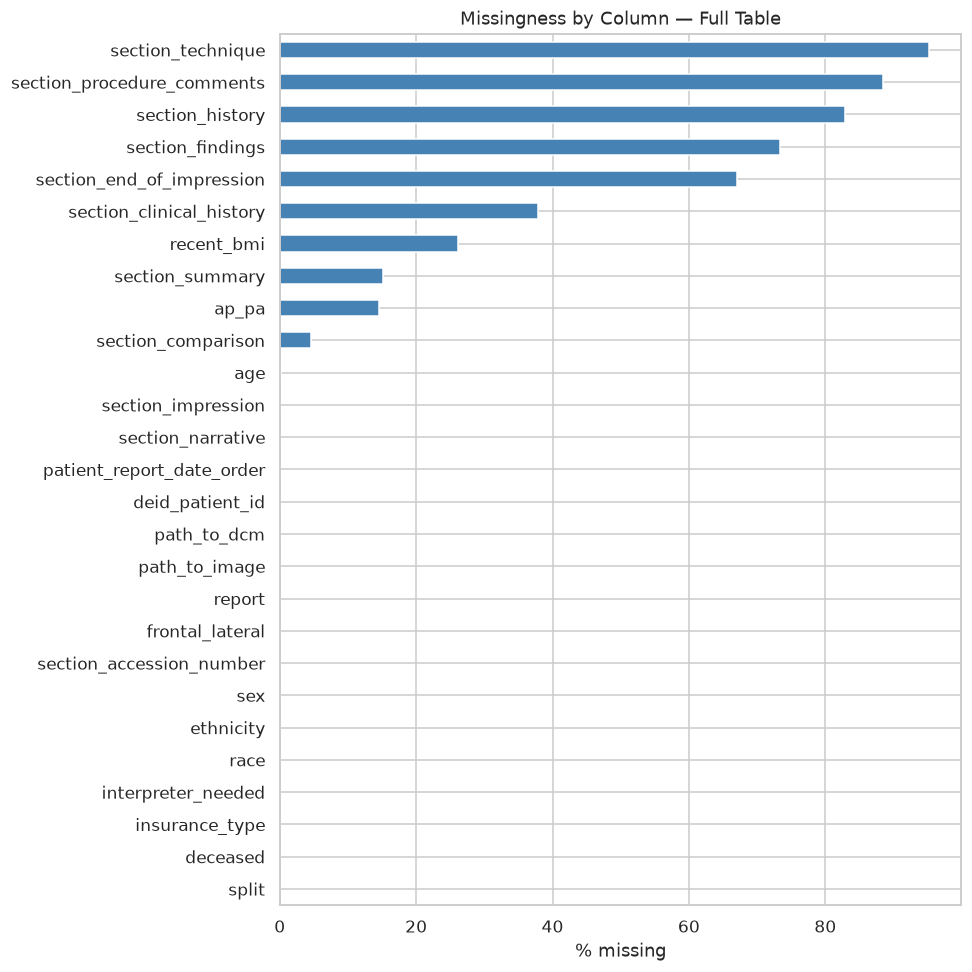

,pct_missing
section_technique,95.20
section_procedure_comments,88.51
section_history,82.91
section_findings,73.39
section_end_of_impression,67.00
section_clinical_history,37.86
recent_bmi,26.17
section_summary,15.13
ap_pa,14.50
section_comparison,4.63


In [8]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 9))
missing_pct.plot(kind="barh", color="steelblue")
plt.xlabel("% missing")
plt.title("Missingness by Column — Full Table")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

missing_pct.to_frame("pct_missing").round(2)

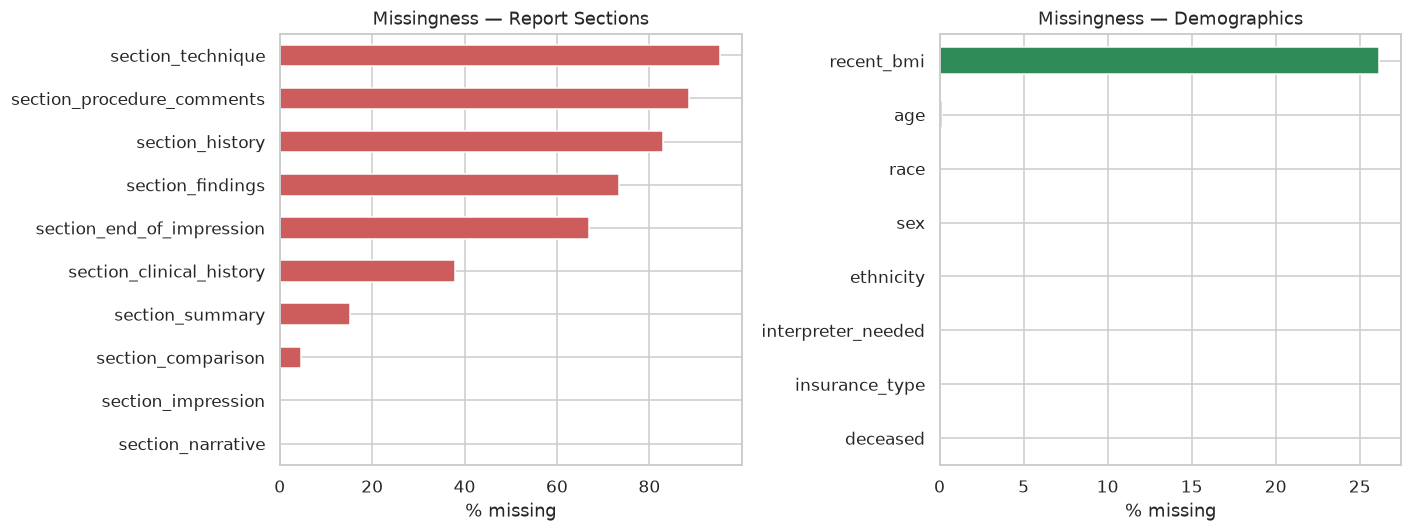

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df[SECTION_COLS].isna().mean().sort_values(ascending=False).mul(100).plot(
    kind="barh", ax=axes[0], color="indianred"
)
axes[0].set_title("Missingness — Report Sections")
axes[0].set_xlabel("% missing")
axes[0].invert_yaxis()

df[DEMO_COLS].isna().mean().sort_values(ascending=False).mul(100).plot(
    kind="barh", ax=axes[1], color="seagreen"
)
axes[1].set_title("Missingness — Demographics")
axes[1].set_xlabel("% missing")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**RAG implication:** any section with high missingness (commonly
`section_procedure_comments`, `section_end_of_impression`, `section_summary`)
is a poor default retrieval field — a RAG pipeline should retrieve from a
field with near-complete coverage (typically `report` or `section_findings` +
`section_impression`) and treat the sparser sections as optional enrichment.

## 5. Parsing `path_to_image` / `path_to_dcm`

CheXpert-style paths follow `<split>/patient<ID>/study<N>/view<K>_<frontal|lateral>[_<ap|pa>].jpg`.
We parse both the image and DICOM paths and cross-check them against the
`split`, `frontal_lateral`, and `ap_pa` columns already in the table.

In [10]:
pattern = re.compile(
    r"(?P<parsed_split>[^/]+)/patient(?P<patient_id>\d+)/study(?P<study_id>\d+)/"
    r"view(?P<view_id>\d+)_(?P<view_position>\w+)"
)

extracted = df["path_to_image"].astype(str).str.extract(pattern)
df = pd.concat([df, extracted], axis=1)

n_unparsed = df["patient_id"].isna().sum()
print(f"Rows that failed to parse path_to_image: {n_unparsed} / {len(df)}")

# Cross-check parsed split vs. the split column, and parsed patient_id vs. deid_patient_id
if "split" in df.columns:
    split_mismatch = (df["parsed_split"] != df["split"]).sum()
    print(f"parsed_split != split column: {split_mismatch}")

if "deid_patient_id" in df.columns:
    # deid_patient_id may carry its own prefix/format — compare on the numeric suffix
    deid_numeric = df["deid_patient_id"].astype(str).str.extract(r"(\d+)$")[0]
    patient_mismatch = (deid_numeric != df["patient_id"]).sum()
    print(f"Numeric suffix of deid_patient_id != parsed patient_id from path: {patient_mismatch}")

df[["path_to_image", "parsed_split", "patient_id", "study_id", "view_id", "view_position"]].head()

Rows that failed to parse path_to_image: 0 / 223462
parsed_split != split column: 0
Numeric suffix of deid_patient_id != parsed patient_id from path: 0


,path_to_image,parsed_split,patient_id,study_id,view_id,view_position
0,train/patient00003/study1/view1_frontal.jpg,train,00003,1,1,frontal
1,train/patient00007/study2/view1_frontal.jpg,train,00007,2,1,frontal
2,train/patient00007/study1/view1_frontal.jpg,train,00007,1,1,frontal
3,train/patient00009/study1/view2_lateral.jpg,train,00009,1,2,lateral
4,train/patient00009/study1/view1_frontal.jpg,train,00009,1,1,frontal


In [11]:
if "path_to_dcm" in df.columns:
    dcm_extracted = df["path_to_dcm"].astype(str).str.extract(pattern)
    dcm_mismatch = (dcm_extracted["patient_id"] != df["patient_id"]).sum()
    dcm_null = df["path_to_dcm"].isna().mean() * 100
    print(f"path_to_dcm missing: {dcm_null:.2f}%")
    print(f"path_to_dcm patient_id disagrees with path_to_image patient_id: {dcm_mismatch} rows")
else:
    print("path_to_dcm not present in this export.")

path_to_dcm missing: 0.00%
path_to_dcm patient_id disagrees with path_to_image patient_id: 0 rows


## 6. Structural Counts — Patients, Studies, Images, Views

In [12]:
n_images = len(df)
n_studies = df[["patient_id", "study_id"]].drop_duplicates().shape[0]
n_patients = df["patient_id"].nunique()

print(f"Images (rows):            {n_images:,}")
print(f"Unique studies:           {n_studies:,}")
print(f"Unique patients:          {n_patients:,}")
print(f"Avg. images per study:    {n_images / n_studies:.2f}")
print(f"Avg. studies per patient: {n_studies / n_patients:.2f}")

Images (rows):            223,462
Unique studies:           187,711
Unique patients:          64,725
Avg. images per study:    1.19
Avg. studies per patient: 2.90


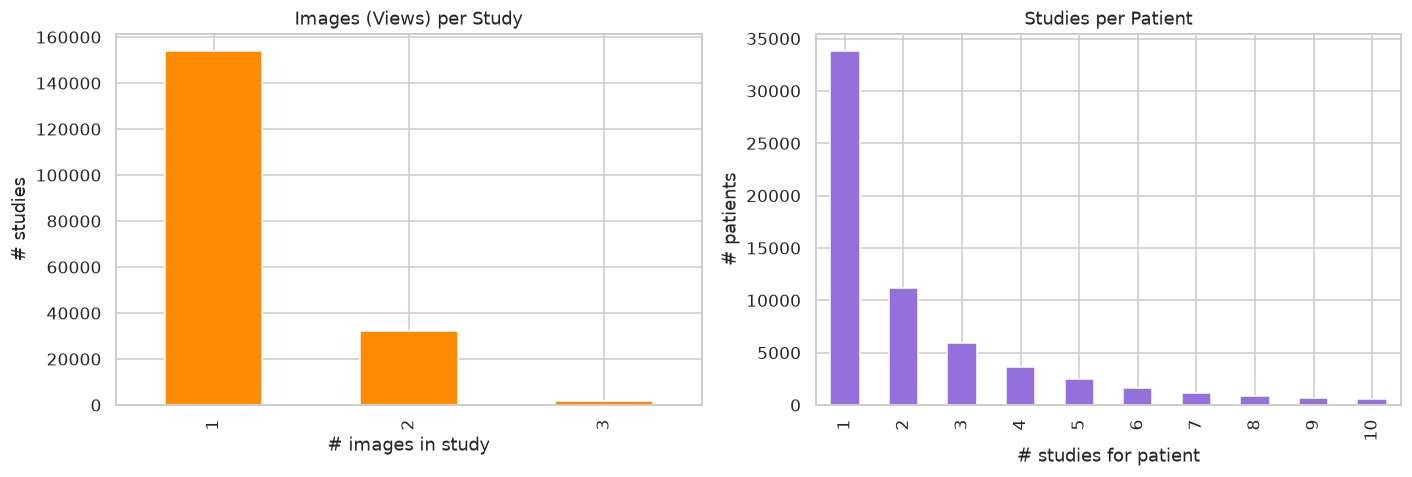

count    187711.000000
mean          1.190458
std           0.416087
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
dtype: float64

count    64725.000000
mean         2.900131
std          4.181931
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         91.000000
Name: study_id, dtype: float64


In [13]:
views_per_study = df.groupby(["patient_id", "study_id"]).size()
studies_per_patient = df.groupby("patient_id")["study_id"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

views_per_study.value_counts().sort_index().head(10).plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("Images (Views) per Study")
axes[0].set_xlabel("# images in study")
axes[0].set_ylabel("# studies")

studies_per_patient.value_counts().sort_index().head(10).plot(kind="bar", ax=axes[1], color="mediumpurple")
axes[1].set_title("Studies per Patient")
axes[1].set_xlabel("# studies for patient")
axes[1].set_ylabel("# patients")

plt.tight_layout()
plt.show()

print(views_per_study.describe())
print()
print(studies_per_patient.describe())

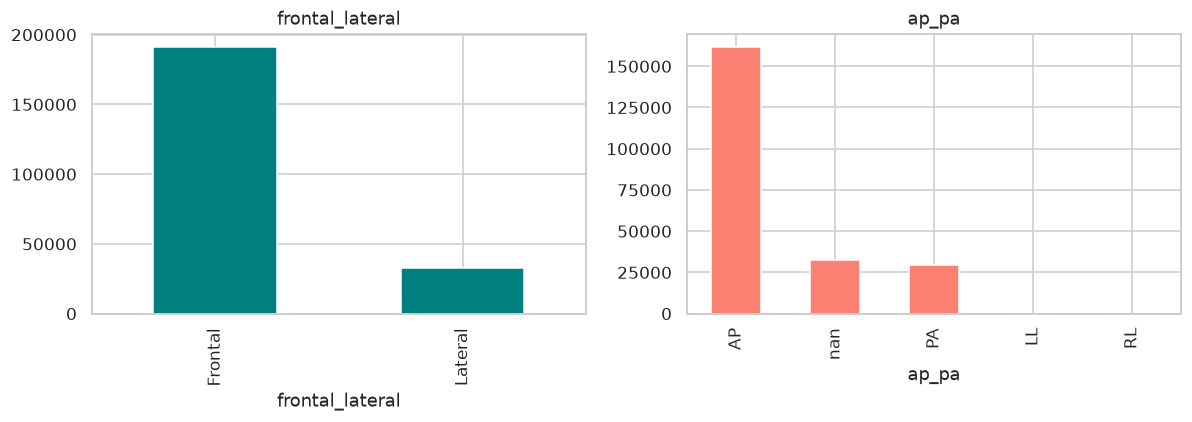

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

if "frontal_lateral" in df.columns:
    df["frontal_lateral"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="teal")
    axes[0].set_title("frontal_lateral")

if "ap_pa" in df.columns:
    df["ap_pa"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], color="salmon")
    axes[1].set_title("ap_pa")

plt.tight_layout()
plt.show()

if {"frontal_lateral", "ap_pa"}.issubset(df.columns):
    pd.crosstab(df["frontal_lateral"], df["ap_pa"], dropna=False, margins=True)

**RAG implication:** if the generation target is a *findings/impression*
report conditioned on a *frontal* view (the typical setup), decide up front
whether lateral-only studies and non-frontal-dominant multi-view studies are
in scope — they change how the image→report pairing key should be built for
both the training set and the retrieval index.

## 7. Split Distribution & Patient Leakage Check

--- Images by split ---
        count   pct
split              
train  223228  99.9
valid     234   0.1

--- Studies by split ---
        count    pct
split               
train  187511  99.89
valid     200   0.11

--- Patients by split ---
       count    pct
split              
train  64525  99.69
valid    200   0.31



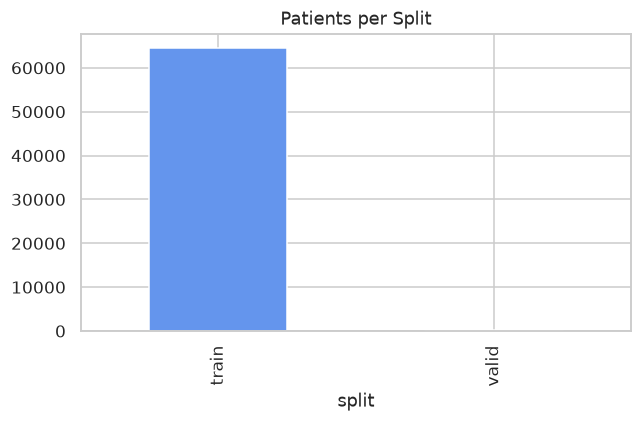

In [15]:
if "split" in df.columns:
    for level, key in [("Images", None), ("Studies", ["patient_id", "study_id"]), ("Patients", ["patient_id"])]:
        if key is None:
            counts = df["split"].value_counts()
        else:
            counts = df.drop_duplicates(subset=key)["split"].value_counts()
        pct = (counts / counts.sum() * 100).round(2)
        print(f"--- {level} by split ---")
        print(pd.DataFrame({"count": counts, "pct": pct}))
        print()

    plt.figure(figsize=(6, 4))
    df.drop_duplicates(subset=["patient_id"])["split"].value_counts().plot(kind="bar", color="cornflowerblue")
    plt.title("Patients per Split")
    plt.tight_layout()
    plt.show()
else:
    print("No `split` column found.")

In [16]:
# Patient leakage: a patient_id should not appear in more than one split.
if "split" in df.columns:
    patient_split_counts = df.groupby("patient_id")["split"].nunique()
    leaked_patients = patient_split_counts[patient_split_counts > 1]
    print(f"Patients appearing in more than one split: {len(leaked_patients)} / {n_patients}")
    if len(leaked_patients):
        display(df[df["patient_id"].isin(leaked_patients.index)][["patient_id", "split"]].drop_duplicates().head(10))

Patients appearing in more than one split: 0 / 64725


**RAG implication:** the RAG **retrieval corpus/index should be built only
from the `train` split** (plus optionally `valid`), never from `test` —
retrieving a test-set report as a "similar prior report" during evaluation is
a leakage path that will silently inflate reported generation quality. The
leakage check above should show **zero** cross-split patients if the official
split is used as-is.

## 8. Patient Demographics

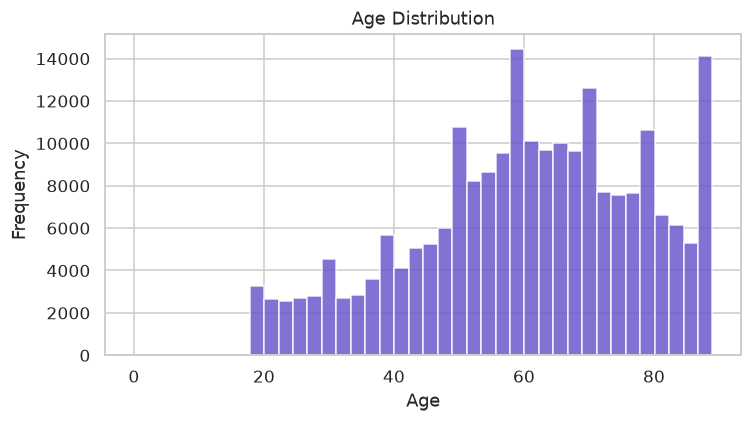

count    223184.000000
mean         60.390938
std          17.770630
min           0.000000
25%          49.000000
50%          62.000000
75%          74.000000
max          89.000000
Name: age, dtype: float64

Rows with age >= 89 (possible HIPAA age top-coding bucket): 9518 (4.26%)


In [17]:
if "age" in df.columns:
    plt.figure(figsize=(7, 4))
    df["age"].plot(kind="hist", bins=40, color="slateblue", alpha=0.85)
    plt.xlabel("Age")
    plt.title("Age Distribution")
    plt.tight_layout()
    plt.show()
    print(df["age"].describe())
    # Common EHR de-identification convention: ages >= 89/90 are top-coded to a single bucket (e.g. HIPAA safe-harbor).
    top_coded = (df["age"] >= 89).sum()
    print(f"\nRows with age >= 89 (possible HIPAA age top-coding bucket): {top_coded} ({top_coded/len(df)*100:.2f}%)")

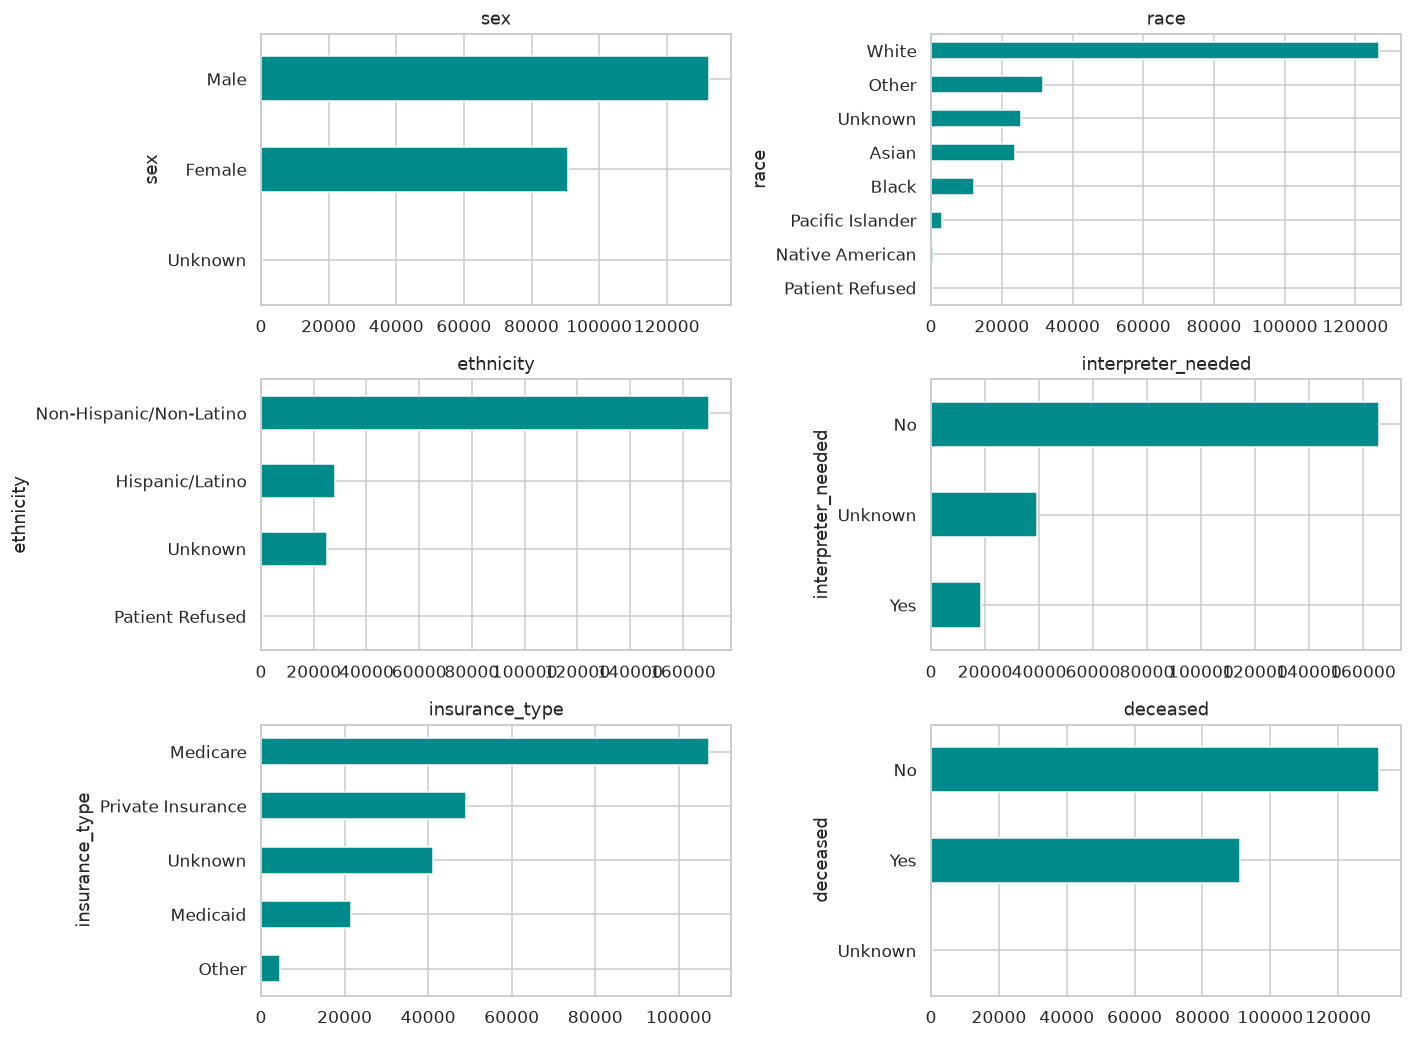

In [18]:
demo_cat_cols = [c for c in ["sex", "race", "ethnicity", "interpreter_needed", "insurance_type", "deceased"] if c in df.columns]

n = len(demo_cat_cols)
fig, axes = plt.subplots((n + 1) // 2, 2, figsize=(13, 3.2 * ((n + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(demo_cat_cols):
    vc = df[col].value_counts(dropna=False).head(15)
    vc.plot(kind="barh", ax=axes[i], color="darkcyan")
    axes[i].set_title(col)
    axes[i].invert_yaxis()

for j in range(len(demo_cat_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

count    164985.000000
mean         26.731495
std           6.510710
min           0.000000
25%          22.300000
50%          25.700000
75%          30.000000
max          50.000000
Name: recent_bmi, dtype: float64

Physiologically implausible BMI (<10 or >80): 41 (0.02% of non-null)


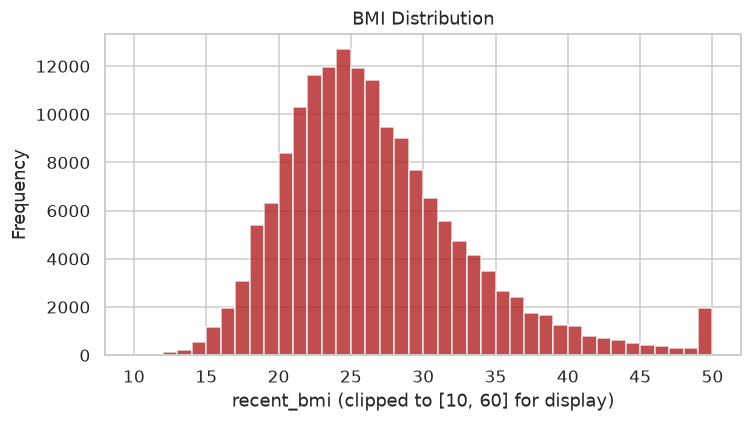

In [19]:
if "recent_bmi" in df.columns:
    bmi = df["recent_bmi"]
    print(bmi.describe())
    # Physiologically implausible BMI values are common data-entry artifacts (e.g. < 10 or > 80)
    implausible = ((bmi < 10) | (bmi > 80)).sum()
    print(f"\nPhysiologically implausible BMI (<10 or >80): {implausible} ({implausible/bmi.notna().sum()*100:.2f}% of non-null)")

    plt.figure(figsize=(7, 4))
    bmi.clip(lower=10, upper=60).plot(kind="hist", bins=40, color="firebrick", alpha=0.8)
    plt.xlabel("recent_bmi (clipped to [10, 60] for display)")
    plt.title("BMI Distribution")
    plt.tight_layout()
    plt.show()

In [20]:
# Patient-level demographic table (one row per patient) — for cohort-level fairness stats
demo_cols_present = [c for c in DEMO_COLS if c in df.columns]
patient_demo = df.drop_duplicates(subset="patient_id")[["patient_id"] + demo_cols_present]
print(f"Unique patients with demographic snapshot: {len(patient_demo):,}")

if {"sex", "race"}.issubset(patient_demo.columns):
    pd.crosstab(patient_demo["race"], patient_demo["sex"], margins=True)

Unique patients with demographic snapshot: 64,725


**RAG implication:** demographics are not part of the retrieval *text*, but
they are the natural stratification variables for **fairness evaluation** of
the generation system — e.g. report quality (factuality, completeness)
broken out by `race`, `sex`, `insurance_type`, and `interpreter_needed`
(interpreter-needed encounters can correlate with reduced note detail in some
EHR corpora and are worth checking explicitly). Keep a patient-level
demographic lookup table alongside the text index so retrieved *and*
generated reports can be audited this way without re-joining raw data every
time.

## 9. Report Section Text Lengths

Word-count and token-count distributions per section — this is the primary
input for deciding **chunk size** and **embedding-model context budget** for
the RAG index.

In [21]:
TEXT_COLS = [c for c in (["report"] + SECTION_COLS) if c in df.columns]

len_stats = []
for col in TEXT_COLS:
    s = df[col].dropna().astype(str)
    words = s.str.split().str.len()
    chars = s.str.len()
    len_stats.append({
        "section": col,
        "n_present": len(s),
        "pct_present": len(s) / len(df) * 100,
        "words_mean": words.mean(), "words_median": words.median(),
        "words_p90": words.quantile(0.90), "words_p99": words.quantile(0.99), "words_max": words.max(),
        "chars_mean": chars.mean(),
    })

len_stats_df = pd.DataFrame(len_stats).set_index("section").round(1)
len_stats_df

,n_present,pct_present,words_mean,words_median,words_p90,words_p99,words_max,chars_mean
section,,,,,,,,
report,223462,100.0,117.4,110.0,164.0,261.0,828,842.4
section_narrative,223434,100.0,5.7,5.0,9.0,19.0,146,40.5
section_clinical_history,138866,62.1,6.9,6.0,11.0,20.0,133,49.1
section_history,38192,17.1,6.6,6.0,11.0,19.0,199,45.7
section_comparison,213125,95.4,2.8,1.0,7.0,14.0,225,22.9
section_technique,10732,4.8,7.0,7.0,9.0,22.0,257,43.9
section_procedure_comments,25669,11.5,5.4,5.0,5.0,17.0,94,31.6
section_findings,59469,26.6,60.8,54.0,104.0,187.0,509,428.7
section_impression,223317,99.9,41.8,38.0,69.0,112.0,425,302.9


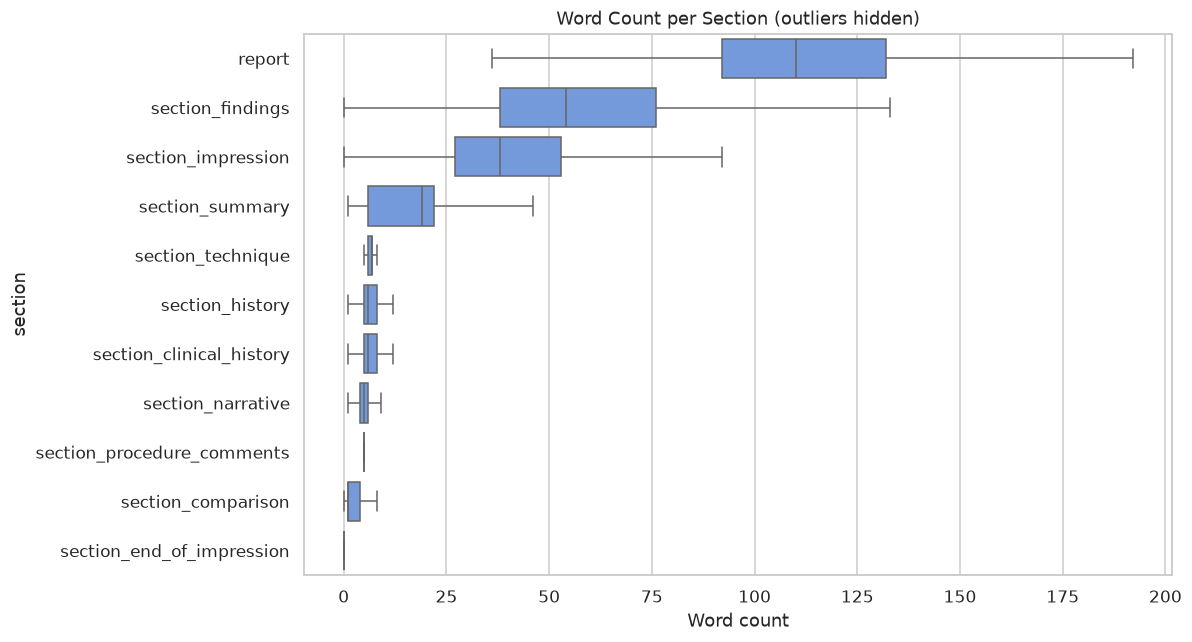

In [22]:
plot_cols = [c for c in TEXT_COLS if df[c].notna().sum() > 0]
melt_rows = []
for col in plot_cols:
    words = df[col].dropna().astype(str).str.split().str.len()
    melt_rows.append(pd.DataFrame({"section": col, "word_count": words}))
melted = pd.concat(melt_rows, ignore_index=True)

plt.figure(figsize=(11, 6))
order = melted.groupby("section")["word_count"].median().sort_values(ascending=False).index
sns.boxplot(data=melted, y="section", x="word_count", order=order, showfliers=False, color="cornflowerblue")
plt.title("Word Count per Section (outliers hidden)")
plt.xlabel("Word count")
plt.tight_layout()
plt.show()

In [23]:
# Precise token counts (tiktoken if available) for the two fields most likely to seed a RAG index
for col in [c for c in ["report", "section_findings", "section_impression"] if c in df.columns]:
    tok = df[col].dropna().astype(str).apply(n_tokens)
    print(f"--- {col} — token counts ({TOKEN_METHOD}) ---")
    print(tok.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
    for limit in (256, 512, 1024):
        pct_over = (tok > limit).mean() * 100
        print(f"  % of non-null '{col}' exceeding {limit} tokens: {pct_over:.2f}%")
    print()

--- report — token counts (tiktoken (cl100k_base)) ---
count    223462.000000
mean        245.553311
std          71.605222
min          67.000000
50%         233.000000
90%         328.000000
95%         375.000000
99%         498.000000
max        1464.000000
Name: report, dtype: float64
  % of non-null 'report' exceeding 256 tokens: 34.21%
  % of non-null 'report' exceeding 512 tokens: 0.85%
  % of non-null 'report' exceeding 1024 tokens: 0.01%

--- section_findings — token counts (tiktoken (cl100k_base)) ---
count    59469.000000
mean       102.576754
std         59.498181
min          1.000000
50%         90.000000
90%        174.000000
95%        215.000000
99%        313.000000
max        760.000000
Name: section_findings, dtype: float64
  % of non-null 'section_findings' exceeding 256 tokens: 2.41%
  % of non-null 'section_findings' exceeding 512 tokens: 0.05%
  % of non-null 'section_findings' exceeding 1024 tokens: 0.00%

--- section_impression — token counts (tiktoken (cl100

**RAG implication:** the token-threshold table above tells you directly
whether `report` (the full concatenated note) can be embedded as a single
chunk with a typical embedding model context window (e.g. 512 tokens), or
whether it needs to be split — most CheXpert Plus reports are short chest
X-ray notes, so `section_findings` + `section_impression` alone will usually
fit in one chunk even when the full `report` does not; that argues for
**indexing findings+impression as the primary retrieval unit**, with the full
report kept as metadata for final answer assembly.

## 10. Section Presence Patterns (Template Structure)

Which combinations of sections co-occur? Reports built from different
templates (e.g. portable chest X-ray vs. multi-view exam) will populate a
different subset of `section_*` columns.

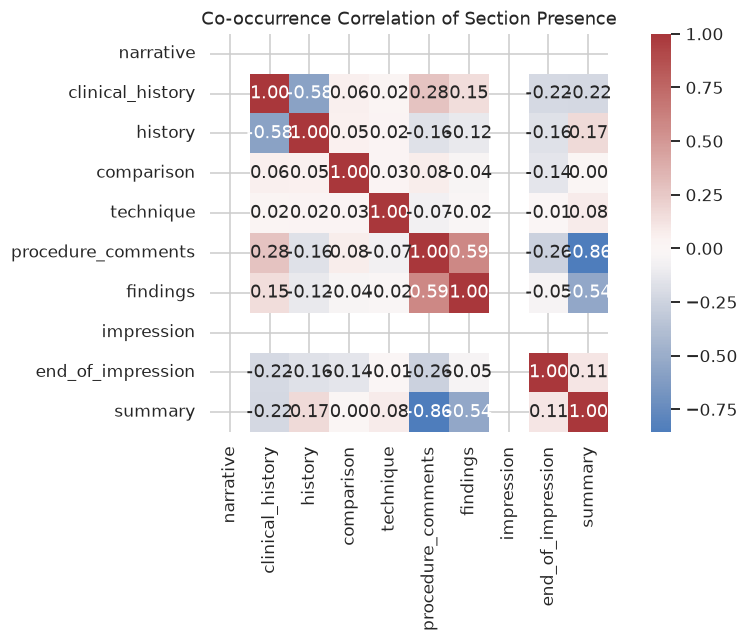

In [24]:
presence = df[SECTION_COLS].notna().astype(int)
presence.columns = [c.replace("section_", "") for c in presence.columns]

plt.figure(figsize=(9, 6))
sns.heatmap(presence.sample(min(3000, len(presence)), random_state=0).corr(), annot=True, fmt=".2f",
            cmap="vlag", center=0, square=True)
plt.title("Co-occurrence Correlation of Section Presence")
plt.tight_layout()
plt.show()

In [25]:
# Most common "template signatures" — which exact set of sections is populated
signature = presence.apply(lambda row: tuple(row.index[row.astype(bool)]), axis=1)
top_signatures = signature.value_counts().head(15)
top_signatures_pct = (top_signatures / len(df) * 100).round(2)

pd.DataFrame({"n_reports": top_signatures, "pct": top_signatures_pct})

,n_reports,pct
"(narrative, clinical_history, comparison, impression, summary)",60750,27.19
"(narrative, history, comparison, impression, summary)",26739,11.97
"(narrative, clinical_history, comparison, procedure_comments, findings, impression)",25397,11.37
"(narrative, clinical_history, comparison, impression, end_of_impression, summary)",22020,9.85
"(narrative, comparison, impression, end_of_impression, summary)",20057,8.98
"(narrative, comparison, impression, summary)",10347,4.63
"(narrative, clinical_history, comparison, findings, impression, summary)",9342,4.18
"(narrative, clinical_history, comparison, findings, impression, end_of_impression, summary)",6080,2.72
"(narrative, comparison, findings, impression, end_of_impression, summary)",5475,2.45
"(narrative, clinical_history, comparison, technique, impression, summary)",3667,1.64


**RAG implication:** if a handful of "template signatures" cover the vast
majority of reports, the RAG prompt-construction step can branch on template
type (e.g. "no clinical history available" vs. "full 6-section report") to
build a consistent context format for the generator, rather than assuming
every retrieved report has the same fields to slot in.

## 11. Structural Validation — Do Sections Compose the Full `report`?

Sanity check that `section_findings` / `section_impression` text is actually
contained within the full `report` string (validates the section-splitting
pipeline the sections were derived from, and confirms `report` is a safe
fallback field when a specific section is missing).

In [26]:
if {"report", "section_findings"}.issubset(df.columns):
    sample = df.dropna(subset=["report", "section_findings"]).sample(min(500, df["section_findings"].notna().sum()), random_state=0)
    contained = sample.apply(lambda r: str(r["section_findings"])[:40].strip() in str(r["report"]), axis=1)
    print(f"section_findings text (first 40 chars) found inside `report`: {contained.mean()*100:.1f}% of sampled rows")

if {"report", "section_impression"}.issubset(df.columns):
    sample = df.dropna(subset=["report", "section_impression"]).sample(min(500, df["section_impression"].notna().sum()), random_state=0)
    contained = sample.apply(lambda r: str(r["section_impression"])[:40].strip() in str(r["report"]), axis=1)
    print(f"section_impression text (first 40 chars) found inside `report`: {contained.mean()*100:.1f}% of sampled rows")

section_findings text (first 40 chars) found inside `report`: 100.0% of sampled rows
section_impression text (first 40 chars) found inside `report`: 100.0% of sampled rows


## 12. Text Quality — De-identification Placeholders & Empty/Boilerplate Strings

In [27]:
# Common de-identification placeholder patterns to watch for before embedding text
DEID_PATTERNS = {
    "underscore_blank": r"_{2,}",         # e.g. "___" replacing a name/date
    "bracket_deid": r"\[\*\*.*?\*\*\]",    # e.g. MIMIC-style [**...**]
    "angle_deid": r"<[A-Z_]+>",            # e.g. <PATIENT_NAME>
}

if "report" in df.columns:
    text = df["report"].dropna().astype(str)
    for name, pat in DEID_PATTERNS.items():
        hit_rate = text.str.contains(pat, regex=True).mean() * 100
        print(f"`report` rows containing '{name}' pattern ({pat}): {hit_rate:.2f}%")

`report` rows containing 'underscore_blank' pattern (_{2,}): 4.19%
`report` rows containing 'bracket_deid' pattern (\[\*\*.*?\*\*\]): 0.00%
`report` rows containing 'angle_deid' pattern (<[A-Z_]+>): 0.00%


In [28]:
# Whitespace-only / trivially short section values (present but uninformative)
for col in TEXT_COLS:
    s = df[col].dropna().astype(str)
    trivial = (s.str.strip().str.len() < 3).sum()
    if trivial:
        print(f"{col}: {trivial} non-null values with <3 characters after stripping (likely placeholder/blank)")

section_narrative: 5526 non-null values with <3 characters after stripping (likely placeholder/blank)
section_clinical_history: 47 non-null values with <3 characters after stripping (likely placeholder/blank)
section_history: 9 non-null values with <3 characters after stripping (likely placeholder/blank)
section_comparison: 162 non-null values with <3 characters after stripping (likely placeholder/blank)
section_technique: 43 non-null values with <3 characters after stripping (likely placeholder/blank)
section_findings: 1407 non-null values with <3 characters after stripping (likely placeholder/blank)
section_impression: 23 non-null values with <3 characters after stripping (likely placeholder/blank)
section_end_of_impression: 68768 non-null values with <3 characters after stripping (likely placeholder/blank)
section_summary: 692 non-null values with <3 characters after stripping (likely placeholder/blank)


**RAG implication:** if de-identification placeholders show up at a
meaningful rate, they should be normalized (e.g. collapsed to a single
`[REDACTED]` token) **before** embedding — otherwise variable-length runs of
underscores/brackets add noise to embeddings and can leak into generated
text verbatim if the LLM copies retrieved context too literally.

## 13. Duplicate & Near-Duplicate Report Detection

Exact and template-boilerplate duplicates inflate a retrieval index (the same
report — or a near-empty templated one — gets retrieved repeatedly) and can
also leak across splits if not caught.

In [29]:
if "report" in df.columns:
    norm_report = df["report"].dropna().astype(str).str.strip().str.lower()
    exact_dupe_count = norm_report.duplicated(keep=False).sum()
    print(f"Rows whose normalized `report` text is an exact duplicate of another row: {exact_dupe_count:,} "
          f"({exact_dupe_count/len(df)*100:.2f}%)")

    dupe_hashes = norm_report[norm_report.duplicated(keep=False)]
    top_dupe_texts = dupe_hashes.value_counts().head(10)
    print("\nMost frequently repeated exact report texts (likely templated boilerplate, e.g. 'no acute cardiopulmonary process'):")
    for txt, cnt in top_dupe_texts.items():
        print(f"  [{cnt:>4}x] {txt[:100]}{'...' if len(txt) > 100 else ''}")

Rows whose normalized `report` text is an exact duplicate of another row: 4 (0.00%)

Most frequently repeated exact report texts (likely templated boilerplate, e.g. 'no acute cardiopulmonary process'):
  [   2x] narrative:
two view chest.
findings: peripheral prominence of the pulmonary interstitial
markings bi...
  [   2x] narrative:
comparison: none available.
 
impression:
 
cardiomediastinal silhouette is normal.  lung...


In [30]:
if "section_technique" in df.columns:
    top_technique = df["section_technique"].dropna().astype(str).str.strip().value_counts().head(10)
    print("Most common `section_technique` strings (highly templated — low retrieval value):")
    print(top_technique)

if "section_comparison" in df.columns:
    top_comparison = df["section_comparison"].dropna().astype(str).str.strip().value_counts().head(10)
    print("\nMost common `section_comparison` strings:")
    print(top_comparison)

Most common `section_technique` strings (highly templated — low retrieval value):
section_technique
Semi-upright AP view of the chest             713
Frontal and lateral views of the chest.       423
Single frontal view of the chest.             409
Two views of the chest.                       404
Upright AP view of the chest                  346
PA and lateral views of the chest.            333
Portable AP upright view of the chest.        301
PA and lateral views of the chest             262
Portable AP semi-erect view of the chest.     232
Portable AP semiupright view of the chest.    192
Name: count, dtype: int64

Most common `section_comparison` strings:
section_comparison
None.                                                 14083
None                                                   7204
NONE.                                                  1524
None available.                                        1109
There are no prior films available for comparison.      531
None availab

**RAG implication:** near-duplicate/boilerplate detection should feed a
**dedup + down-weighting step** before indexing — either drop rows whose
`report` text is an exact duplicate of an already-indexed report (or cap how
many copies of a given boilerplate text are retrievable), and exclude
`section_technique`/`section_comparison` from the embedded text entirely,
since they're near-constant strings that add no discriminative signal to
similarity search.

## 14. Multi-Label Cross-Check (if label CSVs are available)

In [31]:
# If findings.csv / report.csv label files (from the companion EDA notebooks) are on disk,
# this merges in `No Finding` so report length / structure can be compared against
# "normal" vs "abnormal" studies. Skips gracefully if not found.
LABEL_FILE_CANDIDATES = ["report.csv", "findings.csv"]
label_df = None
for f in LABEL_FILE_CANDIDATES:
    if Path(f).exists():
        label_df = pd.read_csv(f, usecols=lambda c: c in ("path_to_image", "No Finding"))
        print(f"Loaded labels from {f} for cross-check.")
        break

if label_df is not None and "path_to_image" in df.columns:
    merged = df.merge(label_df, on="path_to_image", how="left")
    if "report" in merged.columns:
        wc = merged["report"].dropna().astype(str).str.split().str.len()
        grp = merged.loc[wc.index].groupby(merged.loc[wc.index, "No Finding"])
        print(wc.groupby(merged.loc[wc.index, "No Finding"]).describe())
else:
    print("No label CSV found alongside this notebook — skipping. "
          "(Not required; run the findings/impression/report EDA notebooks separately.)")

Loaded labels from report.csv for cross-check.
              count        mean        std   min   25%    50%    75%    max
No Finding                                                                 
1.0         13053.0  116.607523  38.812144  36.0  92.0  109.0  132.0  808.0


## 15. RAG System Design Summary

Consolidates the findings above into concrete parameters for the retrieval
corpus.

In [32]:
train_mask = df["split"].eq("train") if "split" in df.columns else pd.Series(True, index=df.index)

corpus_candidates = {}
if "report" in df.columns:
    corpus_candidates["report"] = df.loc[train_mask, "report"].notna().sum()
if {"section_findings", "section_impression"}.issubset(df.columns):
    both = df["section_findings"].notna() & df["section_impression"].notna()
    corpus_candidates["section_findings + section_impression"] = (train_mask & both).sum()
if "section_findings" in df.columns:
    corpus_candidates["section_findings only"] = (train_mask & df["section_findings"].notna()).sum()

print("Candidate RAG index sizes (train split, by retrieval-unit choice):")
for k, v in corpus_candidates.items():
    print(f"  {k:45s}: {v:,} indexable documents")

if "report" in df.columns:
    dedupe_savings = df.loc[train_mask, "report"].dropna().astype(str).str.strip().str.lower().duplicated().sum()
    print(f"\nExact-duplicate reports in train split (would be dropped after dedup): {dedupe_savings:,}")

Candidate RAG index sizes (train split, by retrieval-unit choice):
  report                                       : 223,228 indexable documents
  section_findings + section_impression        : 59,364 indexable documents
  section_findings only                        : 59,395 indexable documents

Exact-duplicate reports in train split (would be dropped after dedup): 2


In [33]:
recommendations = pd.DataFrame([
    {"decision": "Retrieval unit", "recommendation": "section_findings + section_impression (falls back to full `report` when either is missing)"},
    {"decision": "Corpus scope", "recommendation": "train split only, after exact-duplicate removal (Section 13)"},
    {"decision": "Chunking", "recommendation": "Single chunk per report in most cases (Section 9 token analysis) — verify the >512-token tail and split only those"},
    {"decision": "Text normalization", "recommendation": "Collapse de-id placeholders (Section 12) to a single token before embedding"},
    {"decision": "Excluded fields", "recommendation": "section_technique, section_comparison — near-constant boilerplate (Section 13), keep as structured metadata instead of embedding"},
    {"decision": "Image-to-text key", "recommendation": "patient_id/study_id/view_id parsed from path_to_image (Section 5); decide frontal-only vs. all-views policy (Section 6)"},
    {"decision": "Fairness slicing", "recommendation": "Evaluate generation quality stratified by race, sex, insurance_type, interpreter_needed (Section 8)"},
    {"decision": "Leakage guard", "recommendation": "Confirm zero cross-split patients (Section 7) before finalizing the index"},
])
recommendations

,decision,recommendation
0,Retrieval unit,section_findings + section_impression (falls back to full `report` when either is missing)
1,Corpus scope,"train split only, after exact-duplicate removal (Section 13)"
2,Chunking,Single chunk per report in most cases (Section 9 token analysis) — verify the >512-token tail and split only those
3,Text normalization,Collapse de-id placeholders (Section 12) to a single token before embedding
4,Excluded fields,"section_technique, section_comparison — near-constant boilerplate (Section 13), keep as structured metadata instead ..."
5,Image-to-text key,patient_id/study_id/view_id parsed from path_to_image (Section 5); decide frontal-only vs. all-views policy (Section 6)
6,Fairness slicing,"Evaluate generation quality stratified by race, sex, insurance_type, interpreter_needed (Section 8)"
7,Leakage guard,Confirm zero cross-split patients (Section 7) before finalizing the index


## 16. Export Summary Artifacts

Saves key tables for reuse in the RAG pipeline build-out / write-up.

In [34]:
out_dir = Path("eda_outputs")
out_dir.mkdir(exist_ok=True)

missing_pct.to_frame("pct_missing").to_csv(out_dir / "report_table_missingness.csv")
len_stats_df.to_csv(out_dir / "section_length_stats.csv")
top_signatures.to_frame("n_reports").to_csv(out_dir / "template_signature_counts.csv")
recommendations.to_csv(out_dir / "rag_design_recommendations.csv", index=False)

print("Saved summary artifacts to:", out_dir.resolve())

Saved summary artifacts to: /home/yash/Documents/Major/eda_outputs


## 17. Key Takeaways (fill in after running)

- Dataset size: **`{n_studies}` studies, `{n_patients}` patients, `{n_images}` images/reports** (see Section 6).
- Split sizes and patient-leakage result (see Section 7): ___
- Section missingness — fields safe to rely on vs. optional (see Section 4): ___
- Report/section length distribution and % over token budget (see Section 9): ___
- Dominant template signature(s) and their share of the corpus (see Section 10): ___
- Exact-duplicate rate in `report` text, train split (see Section 13): ___
- Final RAG index size after scoping + dedup (see Section 15): ___
- Any demographic skew worth flagging for fairness evaluation (see Section 8): ___

*(This notebook is complementary to the existing `chexpert_plus_findings_eda.ipynb`,
`chexpert_plus_impression_eda.ipynb`, and `chexpert_plus_report_eda.ipynb`, which
cover the 14 pathology label distributions in depth.)*